In [18]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, chi2_contingency
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, classification_report,precision_recall_curve, average_precision_score,confusion_matrix)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import shap
from tqdm import tqdm
import os

In [20]:
# River for online drift detection
from river import drift
# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

In [22]:
TRAIN_TRANS = r'C:\Users\91704\Downloads\ieee-fraud-detection\train_transaction.csv'
TRAIN_ID    = r'C:\Users\91704\Downloads\ieee-fraud-detection\train_identity.csv'

In [24]:
df_trans = pd.read_csv(TRAIN_TRANS)
print(f"   Transaction shape: {df_trans.shape}")
df_id = pd.read_csv(TRAIN_ID)
print(f"   Identity shape: {df_id.shape}")

   Transaction shape: (590540, 394)
   Identity shape: (144233, 41)


In [30]:
df = df_trans.merge(df_id, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")

print(f"Fraud Rate: {df['isFraud'].mean()*100:.2f}%")
print(f"TransactionDT range: {df['TransactionDT'].min()} → {df['TransactionDT'].max()}")

df.head(3)

Merged shape: (590540, 434)
Fraud Rate: 3.50%
TransactionDT range: 86400 → 15811131


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
SECONDS_PER_DAY = 86400
df['day'] = (df['TransactionDT'] // SECONDS_PER_DAY).astype(int)
df['week'] = (df['day'] // 7).astype(int)
df['month_bin'] = (df['day'] // 30).astype(int)

# Normalize month_bin to start from 0
df['month_bin'] = df['month_bin'] - df['month_bin'].min()

print(f"Number of unique days: {df['day'].nunique()}")
print(f"Number of weekly windows: {df['week'].nunique()}")
print(f"Number of monthly windows: {df['month_bin'].nunique()}")

# Fraud rate per monthly window
fraud_by_month = df.groupby('month_bin').agg(
    fraud_rate=('isFraud', 'mean'),
    total=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum')
).reset_index()

Number of unique days: 182
Number of weekly windows: 27
Number of monthly windows: 7


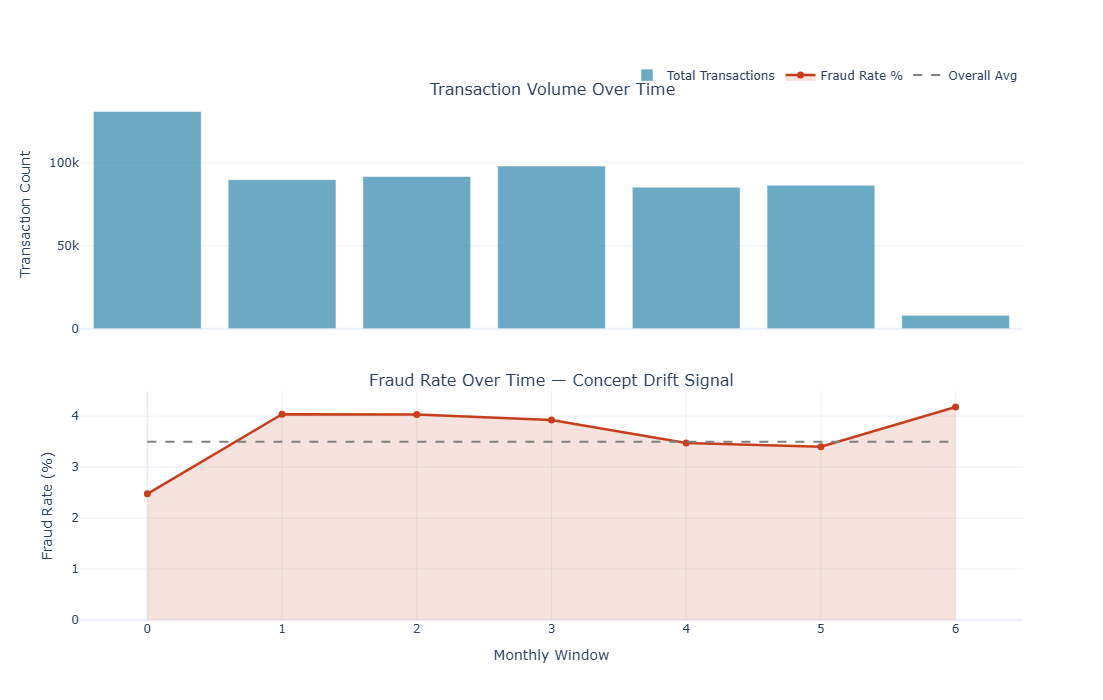

In [66]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    subplot_titles=('Transaction Volume Over Time', 'Fraud Rate Over Time — Concept Drift Signal')
)
fig.add_trace(
    go.Bar(
        x=fraud_by_month['month_bin'],
        y=fraud_by_month['total'],
        name='Total Transactions',
        marker_color='#2E86AB',
        opacity=0.7
    ),
    row=1, col=1
)
avg_fraud = df['isFraud'].mean() * 100
fig.add_trace(
    go.Scatter(
        x=fraud_by_month['month_bin'],
        y=fraud_by_month['fraud_rate'] * 100,
        name='Fraud Rate %',
        mode='lines+markers',
        line=dict(color='#C73E1D', width=2.5),
        marker=dict(size=7),
        fill='tozeroy',
        fillcolor='rgba(199, 62, 29, 0.15)'
    ),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(
        x=fraud_by_month['month_bin'],
        y=[avg_fraud] * len(fraud_by_month),
        name='Overall Avg',
        mode='lines',
        line=dict(color='gray', dash='dash')
    ),
    row=2, col=1
)
fig.update_layout(
    height=700,
    width=1000,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.update_xaxes(title_text='Monthly Window', row=2, col=1)
fig.update_yaxes(title_text='Transaction Count', row=1, col=1)
fig.update_yaxes(title_text='Fraud Rate (%)', row=2, col=1)
fig.show()

In [38]:
NUMERIC_COLS = ['TransactionAmt', 'card1', 'card2', 'card3', 'card5',
                'addr1', 'addr2', 'dist1', 'dist2',
                'C1','C2','C3','C4','C5','C6','C7','C8','C9','C10',
                'C11','C12','C13','C14',
                'D1','D2','D3','D4','D10','D15',
                'V95','V96','V97','V126','V127','V128','V129','V130']

CAT_COLS = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']

TARGET = 'isFraud'
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df.columns]
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

# Label encode categoricals
le = LabelEncoder()
for col in CAT_COLS:
    df[col] = df[col].fillna('missing')
    df[col] = le.fit_transform(df[col].astype(str))

# Fill numerics
for col in NUMERIC_COLS:
    df[col] = df[col].fillna(df[col].median())
    
df['log_TransactionAmt'] = np.log1p(df['TransactionAmt'])

# Amount deviation from card mean
df['amt_card_mean'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['amt_deviation'] = df['TransactionAmt'] - df['amt_card_mean']

FEATURE_COLS = NUMERIC_COLS + CAT_COLS + ['log_TransactionAmt', 'amt_deviation']
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f"Total features: {len(FEATURE_COLS)}")
print(f"Numeric: {len(NUMERIC_COLS)}, Categorical: {len(CAT_COLS)}, Engineered: 2")

Total features: 44
Numeric: 37, Categorical: 5, Engineered: 2


In [40]:
TRAIN_MONTHS = [0, 1, 2, 3]
TEST_MONTHS  = sorted(df['month_bin'].unique()[4:])

df_train = df[df['month_bin'].isin(TRAIN_MONTHS)].copy()
df_test  = df[df['month_bin'].isin(TEST_MONTHS)].copy()

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET]

X_test  = df_test[FEATURE_COLS]
y_test  = df_test[TARGET]

print(f"Training set: {X_train.shape} | Fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test set:     {X_test.shape}  | Fraud rate: {y_test.mean()*100:.2f}%")

Training set: (410601, 44) | Fraud rate: 3.51%
Test set:     (179939, 44)  | Fraud rate: 3.47%


In [42]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

[0]	validation_0-auc:0.82221
[50]	validation_0-auc:0.87634
[100]	validation_0-auc:0.89125
[150]	validation_0-auc:0.89733
[200]	validation_0-auc:0.90086
[250]	validation_0-auc:0.90253
[299]	validation_0-auc:0.90339


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [44]:
y_pred_proba = model.predict_proba(X_test)[:,1]
overall_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Overall Test AUC: {overall_auc:.4f}")

Overall Test AUC: 0.9034


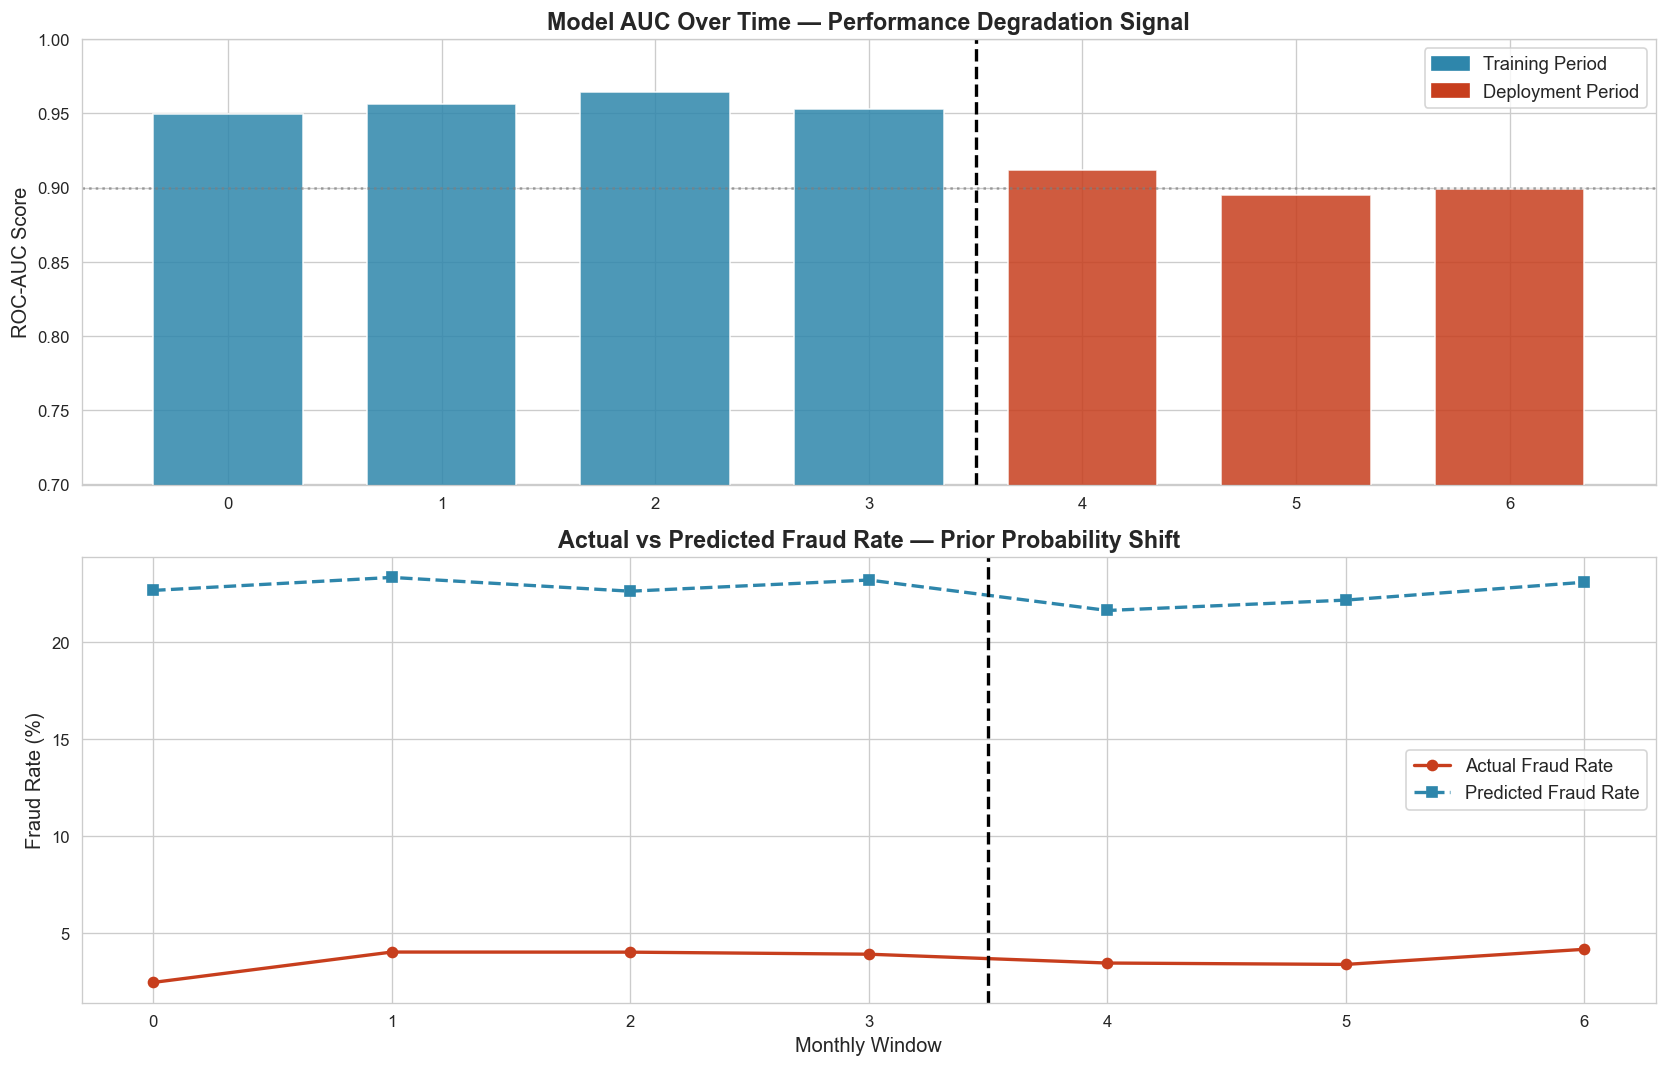

In [74]:
monthly_metrics = []

for month in sorted(df['month_bin'].unique()):
    subset = df[df['month_bin'] == month]
    X_m = subset[FEATURE_COLS]
    y_m = subset[TARGET]
    
    if y_m.sum() < 5 or len(y_m) < 50:
        continue
    
    proba = model.predict_proba(X_m)[:,1]
    auc = roc_auc_score(y_m, proba)
    ap  = average_precision_score(y_m, proba)
    
    monthly_metrics.append({
        'month': month,
        'auc': auc,
        'ap': ap,
        'n': len(y_m),
        'fraud_rate': y_m.mean(),
        'is_train': month in TRAIN_MONTHS
    })

metrics_df = pd.DataFrame(monthly_metrics)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

colors = ['#2E86AB' if t else '#C73E1D' for t in metrics_df['is_train']]

# AUC over time
axes[0].bar(metrics_df['month'], metrics_df['auc'], color=colors, alpha=0.85, width=0.7)
axes[0].axvline(x=3.5, color='black', linestyle='--', linewidth=2, label='Train/Test Split')
axes[0].axhline(y=0.9, color='gray', linestyle=':', alpha=0.7, label='AUC=0.9 threshold')
axes[0].set_ylabel('ROC-AUC Score', fontsize=12)
axes[0].set_title('Model AUC Over Time — Performance Degradation Signal', fontsize=14, fontweight='bold')
train_patch = mpatches.Patch(color='#2E86AB', label='Training Period')
test_patch  = mpatches.Patch(color='#C73E1D', label='Deployment Period')
axes[0].legend(handles=[train_patch, test_patch], fontsize=11)
axes[0].set_ylim(0.7, 1.0)

# Fraud rate vs predicted fraud rate
avg_pred = []
for month in sorted(df['month_bin'].unique()):
    subset = df[df['month_bin'] == month]
    if len(subset) < 50: continue
    p = model.predict_proba(subset[FEATURE_COLS])[:,1]
    avg_pred.append({'month': month,
                     'actual_fraud': subset[TARGET].mean(),
                     'pred_fraud': p.mean()})
pred_df = pd.DataFrame(avg_pred)

axes[1].plot(pred_df['month'], pred_df['actual_fraud']*100,
             'o-', color='#C73E1D', label='Actual Fraud Rate', linewidth=2)
axes[1].plot(pred_df['month'], pred_df['pred_fraud']*100,
             's--', color='#2E86AB', label='Predicted Fraud Rate', linewidth=2)
axes[1].axvline(x=3.5, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Monthly Window', fontsize=12)
axes[1].set_ylabel('Fraud Rate (%)', fontsize=12)
axes[1].set_title('Actual vs Predicted Fraud Rate — Prior Probability Shift', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

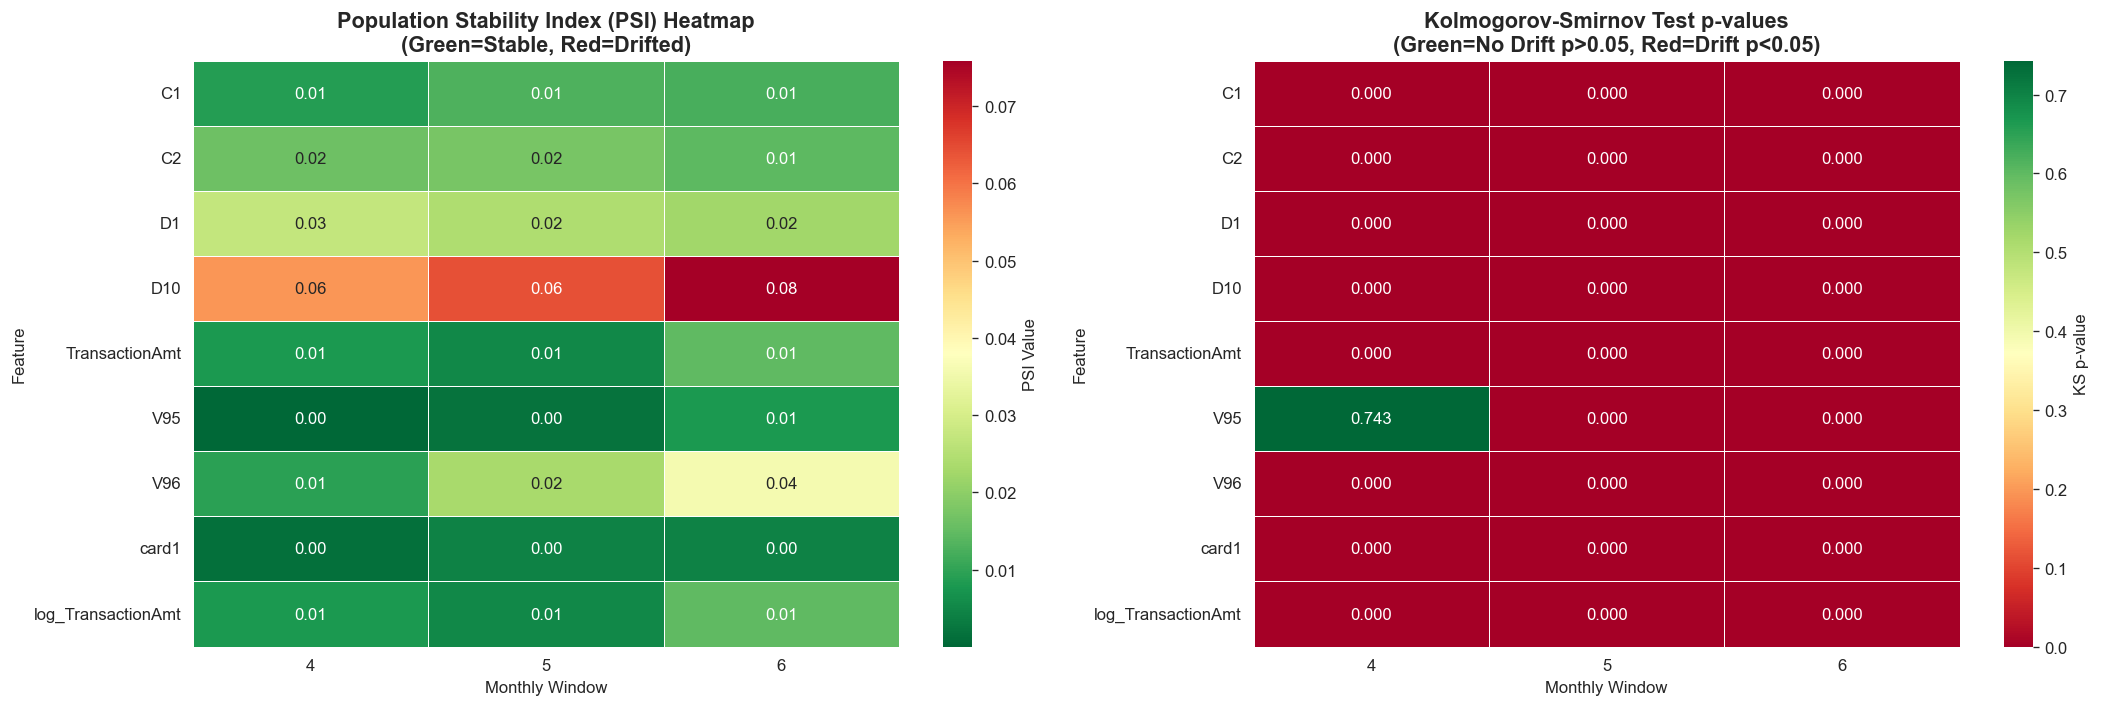

Drift Detection Summary:
feature             psi_label
C1                  No Drift     3
C2                  No Drift     3
D1                  No Drift     3
D10                 No Drift     3
TransactionAmt      No Drift     3
V95                 No Drift     3
V96                 No Drift     3
card1               No Drift     3
log_TransactionAmt  No Drift     3


In [48]:
def compute_psi(expected, actual, bins=10):
    """Population Stability Index"""
    breakpoints = np.linspace(0, 100, bins+1)
    expected_percents = np.histogram(expected, bins=np.percentile(expected, breakpoints))[0] / len(expected)
    actual_percents   = np.histogram(actual,   bins=np.percentile(expected, breakpoints))[0] / len(actual)
    
    # Avoid log(0)
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents   = np.where(actual_percents   == 0, 0.0001, actual_percents)
    
    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi

def psi_interpretation(psi):
    if psi < 0.1:  return "No Drift"
    elif psi < 0.2: return "Minor Drift"
    else:           return "Major Drift"

# Reference distribution = training months
reference_data = df[df['month_bin'].isin(TRAIN_MONTHS)]

# Key features to monitor
MONITOR_FEATURES = ['TransactionAmt', 'log_TransactionAmt', 
                    'C1', 'C2', 'D1', 'D10', 'V95', 'V96', 'card1']
MONITOR_FEATURES = [f for f in MONITOR_FEATURES if f in df.columns]

drift_results = []

for month in sorted(df['month_bin'].unique()):
    if month in TRAIN_MONTHS:
        continue
    
    current_data = df[df['month_bin'] == month]
    
    for feat in MONITOR_FEATURES:
        ref_vals = reference_data[feat].dropna().values
        cur_vals = current_data[feat].dropna().values
        
        if len(cur_vals) < 20:
            continue
        
        # KS Test
        ks_stat, ks_pval = ks_2samp(ref_vals, cur_vals)
        
        # PSI
        psi_val = compute_psi(ref_vals, cur_vals)
        
        drift_results.append({
            'month': month,
            'feature': feat,
            'ks_stat': ks_stat,
            'ks_pval': ks_pval,
            'psi': psi_val,
            'ks_drift': ks_pval < 0.05,
            'psi_label': psi_interpretation(psi_val)
        })

drift_df = pd.DataFrame(drift_results)

# ----- HEATMAP: PSI across features over time -----
psi_pivot = drift_df.pivot(index='feature', columns='month', values='psi')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(psi_pivot, ax=axes[0], cmap='RdYlGn_r', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'PSI Value'})
axes[0].set_title('Population Stability Index (PSI) Heatmap\n(Green=Stable, Red=Drifted)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Window')
axes[0].set_ylabel('Feature')

# KS p-value heatmap
ks_pivot = drift_df.pivot(index='feature', columns='month', values='ks_pval')
sns.heatmap(ks_pivot, ax=axes[1], cmap='RdYlGn', annot=True, fmt='.3f',
            linewidths=0.5, cbar_kws={'label': 'KS p-value'})
axes[1].set_title('Kolmogorov-Smirnov Test p-values\n(Green=No Drift p>0.05, Red=Drift p<0.05)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Window')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

# Summary
print("Drift Detection Summary:")
print(drift_df.groupby('feature')['psi_label'].value_counts().to_string())

   TransactionAmt: 247 drift points detected


   C1: 303 drift points detected


   D1: 133 drift points detected


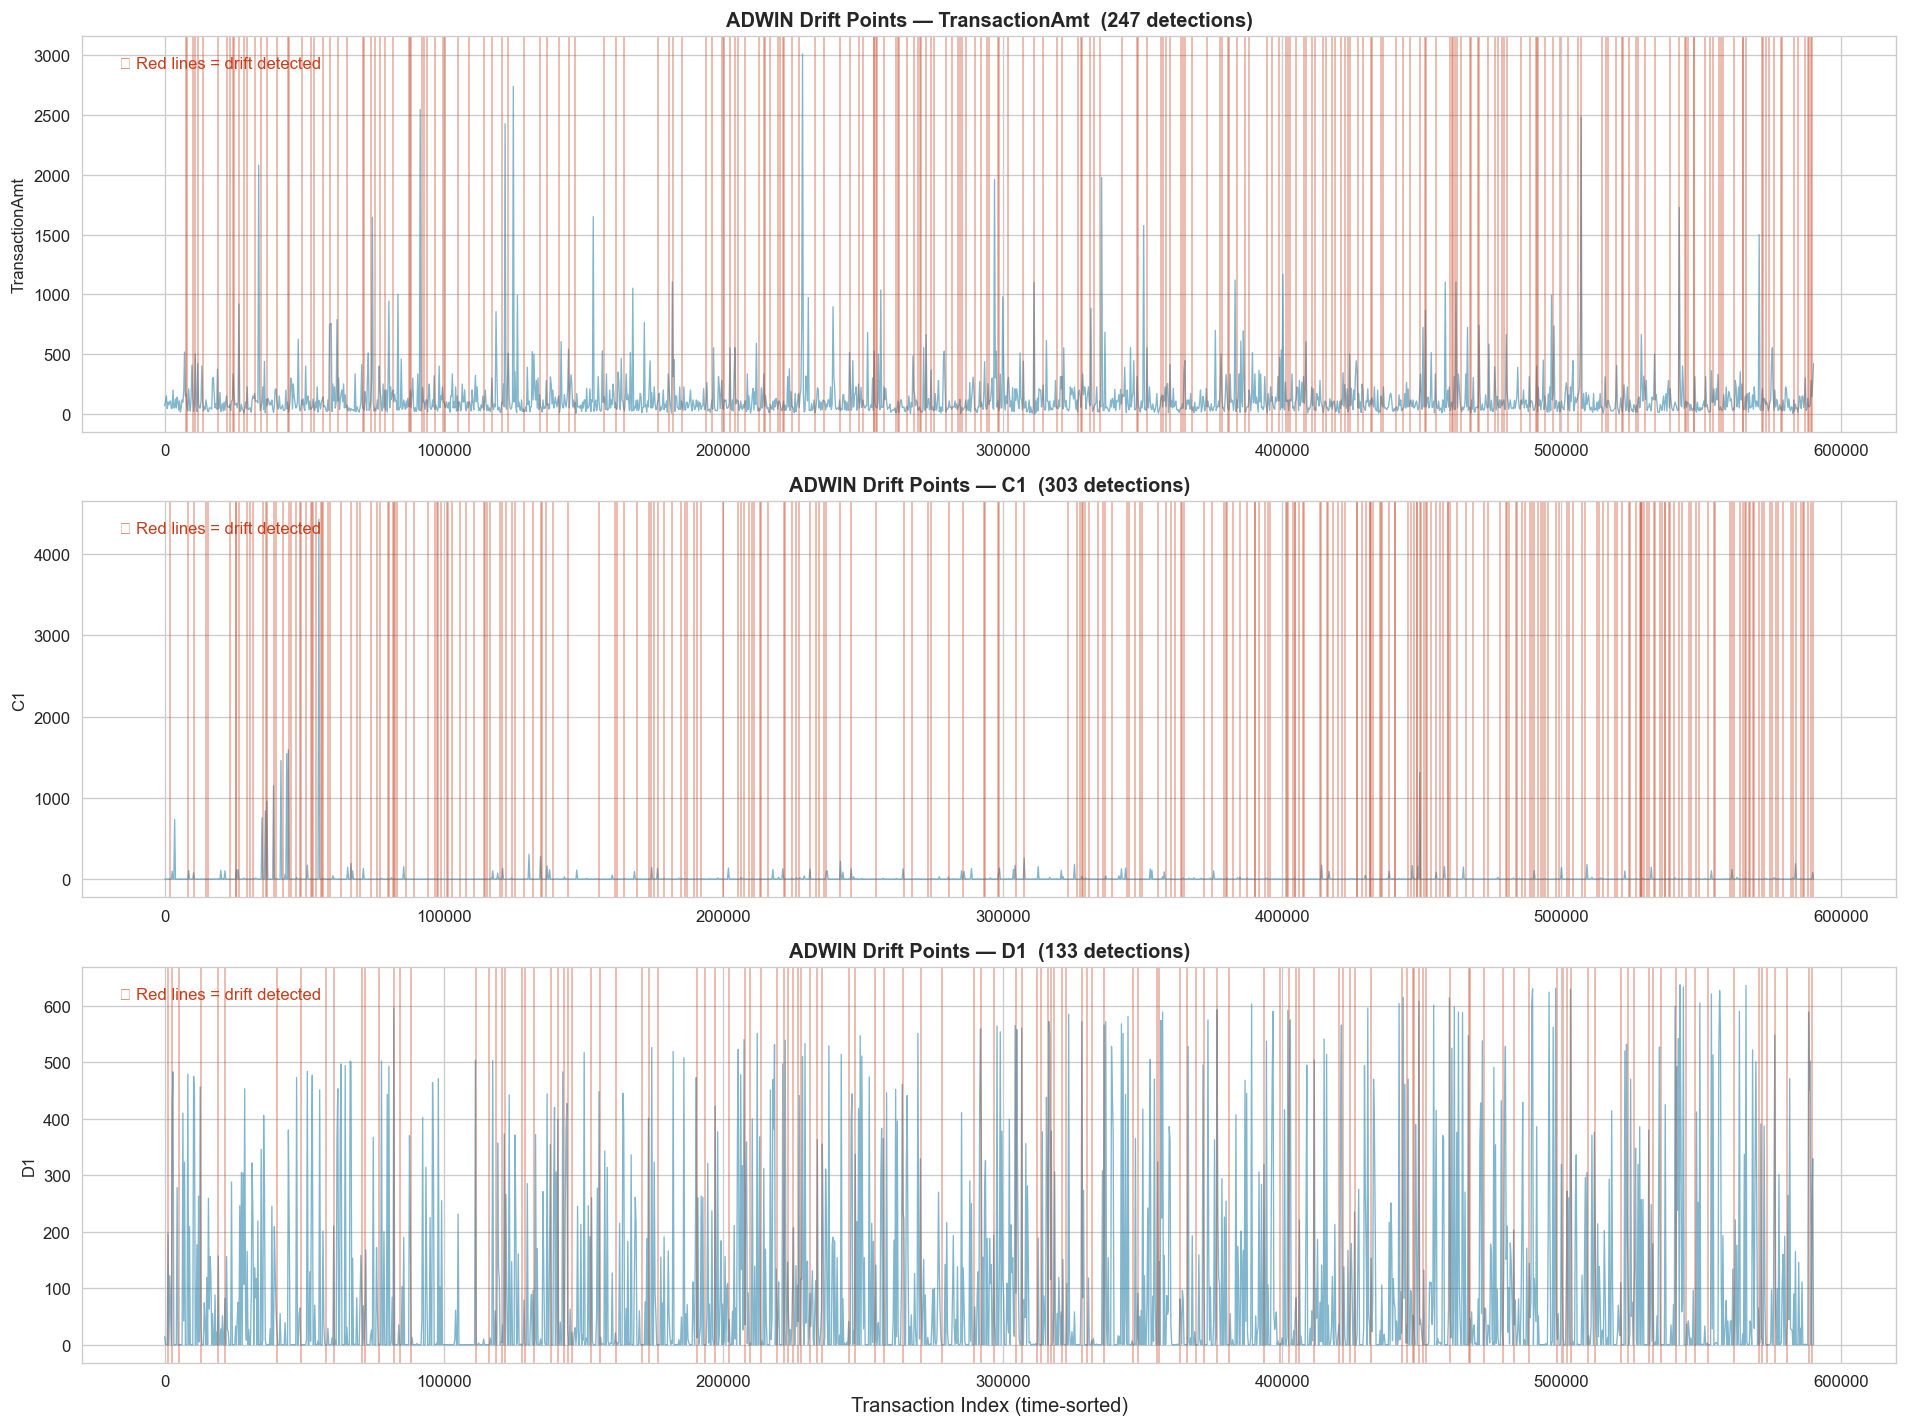

In [50]:
# Sort by time
df_sorted = df.sort_values('TransactionDT').reset_index(drop=True)

features_to_monitor = ['TransactionAmt', 'C1', 'D1']
features_to_monitor = [f for f in features_to_monitor if f in df.columns]

adwin_results = {}

for feat in features_to_monitor:
    adwin = drift.ADWIN(delta=0.002)
    drift_points = []
    
    values = df_sorted[feat].fillna(0).values
    
    for i, val in enumerate(tqdm(values, desc=f"ADWIN on {feat}", leave=False)):
        adwin.update(float(val))
        if adwin.drift_detected:
            drift_points.append(i)
    
    adwin_results[feat] = drift_points
    print(f"   {feat}: {len(drift_points)} drift points detected")

# Plot ADWIN results
fig, axes = plt.subplots(len(features_to_monitor), 1, 
                          figsize=(16, 4*len(features_to_monitor)))
if len(features_to_monitor) == 1:
    axes = [axes]

for idx, feat in enumerate(features_to_monitor):
    # Downsample for visibility
    step = max(1, len(df_sorted) // 2000)
    x = np.arange(len(df_sorted))[::step]
    y = df_sorted[feat].fillna(0).values[::step]
    
    axes[idx].plot(x, y, color='#2E86AB', alpha=0.6, linewidth=0.8)
    
    for dp in adwin_results[feat]:
        axes[idx].axvline(x=dp, color='#C73E1D', alpha=0.4, linewidth=1.0)
    
    axes[idx].set_title(f'ADWIN Drift Points — {feat}  ({len(adwin_results[feat])} detections)', 
                         fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(feat)
    
    # Add annotation
    if adwin_results[feat]:
        axes[idx].annotate('⬆ Red lines = drift detected', 
                           xy=(0.02, 0.92), xycoords='axes fraction',
                           color='#C73E1D', fontsize=10)

axes[-1].set_xlabel('Transaction Index (time-sorted)', fontsize=12)
plt.tight_layout()
plt.show()

   Computing SHAP for early period...
   Computing SHAP for late period...


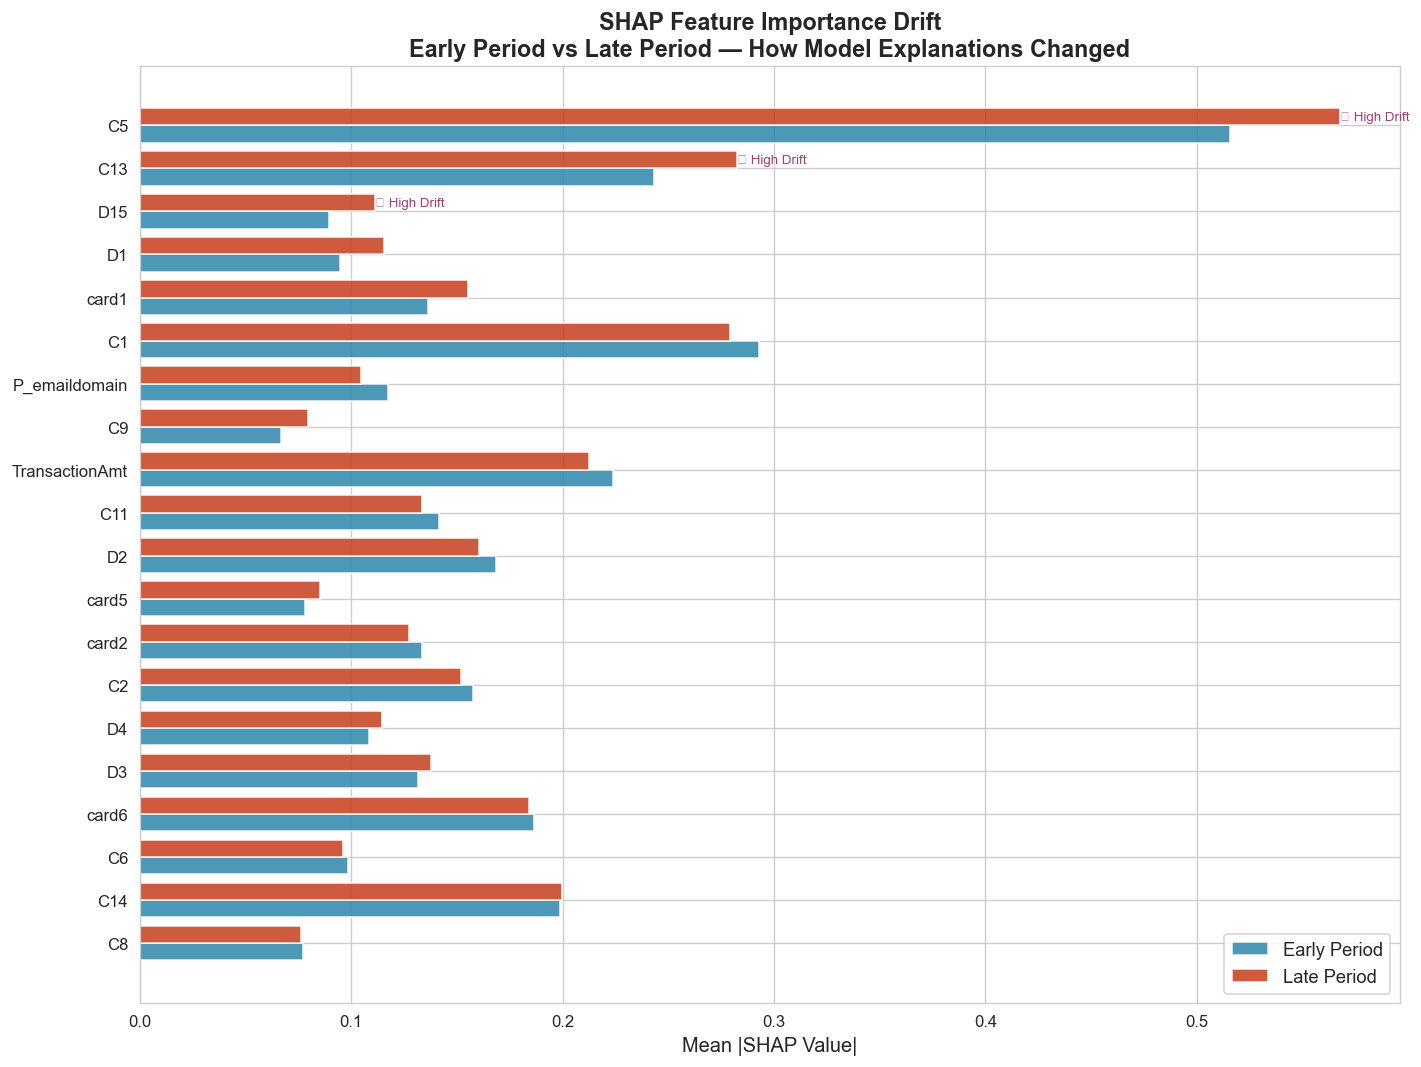

In [52]:
# Compare SHAP importance: early vs late period
early_months = [0, 1, 2]
late_months  = [m for m in sorted(df['month_bin'].unique()) if m >= df['month_bin'].max() - 2]

df_early = df[df['month_bin'].isin(early_months)].sample(min(1000, len(df[df['month_bin'].isin(early_months)])), random_state=42)
df_late  = df[df['month_bin'].isin(late_months)].sample(min(1000, len(df[df['month_bin'].isin(late_months)])), random_state=42)

explainer = shap.TreeExplainer(model)

print("   Computing SHAP for early period...")
shap_early = explainer.shap_values(df_early[FEATURE_COLS])
print("   Computing SHAP for late period...")
shap_late  = explainer.shap_values(df_late[FEATURE_COLS])

# Mean absolute SHAP
early_importance = pd.Series(np.abs(shap_early).mean(axis=0), index=FEATURE_COLS)
late_importance  = pd.Series(np.abs(shap_late).mean(axis=0),  index=FEATURE_COLS)

# Top 20 features
top_feats = (early_importance + late_importance).nlargest(20).index

comparison = pd.DataFrame({
    'Early Period': early_importance[top_feats],
    'Late Period':  late_importance[top_feats]
})

# Sort by drift magnitude
comparison['drift_magnitude'] = abs(comparison['Early Period'] - comparison['Late Period'])
comparison = comparison.sort_values('drift_magnitude', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
y_pos = np.arange(len(comparison))
ax.barh(y_pos - 0.2, comparison['Early Period'], 0.4, 
        color='#2E86AB', alpha=0.85, label='Early Period')
ax.barh(y_pos + 0.2, comparison['Late Period'],  0.4, 
        color='#C73E1D', alpha=0.85, label='Late Period')
ax.set_yticks(y_pos)
ax.set_yticklabels(comparison.index, fontsize=10)
ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('SHAP Feature Importance Drift\nEarly Period vs Late Period — How Model Explanations Changed',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axvline(x=0, color='black', linewidth=0.5)

# Highlight most drifted
top3 = comparison.nlargest(3, 'drift_magnitude').index
for feat in top3:
    idx = list(comparison.index).index(feat)
    ax.annotate('⬅ High Drift', xy=(comparison.loc[feat, 'Late Period'], idx+0.2),
                fontsize=8, color='#A23B72', va='center')

plt.tight_layout()
plt.show()

In [54]:
print("\n" + "="*70)
print("CONCEPT DRIFT AUTOPSY REPORT")
print("="*70)

# 1. Covariate Shift: P(X) changes, P(Y|X) same
print("\nSECTION 1: COVARIATE SHIFT ANALYSIS (P(X) changes)")
print("-"*50)

covariate_drifted = drift_df[drift_df['ks_drift'] == True]['feature'].value_counts()
print(f"  Features showing distributional shift (KS p<0.05):")
for feat, count in covariate_drifted.head(8).items():
    print(f"    • {feat}: detected in {count}/{len(drift_df['month'].unique())} months")

# 2. Prior Probability Shift: P(Y) changes
print("\nSECTION 2: PRIOR PROBABILITY SHIFT (P(Y) changes)")
print("-"*50)
fraud_rate_change = fraud_by_month['fraud_rate'].values
print(f"Initial fraud rate (month 0): {fraud_rate_change[0]*100:.2f}%")
print(f"Final fraud rate  (last month): {fraud_rate_change[-1]*100:.2f}%")
print(f"Relative change: {((fraud_rate_change[-1] - fraud_rate_change[0])/fraud_rate_change[0])*100:.1f}%")
if abs(fraud_rate_change[-1] - fraud_rate_change[0]) > 0.005:
    print("SIGNIFICANT prior probability shift detected!")
else:
    print("Prior probability stable")

# 3. Concept Drift: P(Y|X) changes
print("\n SECTION 3: REAL CONCEPT DRIFT ANALYSIS (P(Y|X) changes)")
print("-"*50)
# Compute accuracy in early vs late period on same X distribution
auc_early = metrics_df[metrics_df['is_train'] == True]['auc'].mean()
auc_late  = metrics_df[metrics_df['is_train'] == False]['auc'].mean()
print(f"  Mean AUC during training period: {auc_early:.4f}")
print(f"  Mean AUC during deployment:      {auc_late:.4f}")
print(f"  AUC degradation:                 {(auc_early - auc_late):.4f}")
if auc_early - auc_late > 0.02:
    print("REAL CONCEPT DRIFT CONFIRMED — Fraudsters changed tactics!")
elif auc_early - auc_late > 0.01:
    print("MILD concept drift — Minor behavioral shifts")
else:
    print("No significant concept drift in P(Y|X)")

# 4. Summary Table
print("\nSECTION 4: DRIFT AUTOPSY VERDICT")
print("-"*50)

findings = {
    "Covariate Shift":         "DETECTED" if len(covariate_drifted) > 3 else "MILD",
    "Prior Prob Shift":        "DETECTED" if abs(fraud_rate_change[-1] - fraud_rate_change[0]) > 0.005 else "STABLE",
    "Real Concept Drift":      "DETECTED" if auc_early - auc_late > 0.02 else "MILD",
    "Feature Importance Drift":" PRESENT (via SHAP analysis)",
    "ADWIN Online Drift":      f"{sum(len(v) for v in adwin_results.values())} drift points across {len(adwin_results)} features"
}

for finding, verdict in findings.items():
    print(f"  {finding:30s}  →  {verdict}")

print("\n" + "="*70)
print("  CONCLUSION: Model requires retraining or drift-adaptation!")
print("="*70)


CONCEPT DRIFT AUTOPSY REPORT

SECTION 1: COVARIATE SHIFT ANALYSIS (P(X) changes)
--------------------------------------------------
  Features showing distributional shift (KS p<0.05):
    • TransactionAmt: detected in 3/3 months
    • log_TransactionAmt: detected in 3/3 months
    • C1: detected in 3/3 months
    • C2: detected in 3/3 months
    • D1: detected in 3/3 months
    • D10: detected in 3/3 months
    • V96: detected in 3/3 months
    • card1: detected in 3/3 months

SECTION 2: PRIOR PROBABILITY SHIFT (P(Y) changes)
--------------------------------------------------
Initial fraud rate (month 0): 2.48%
Final fraud rate  (last month): 4.18%
Relative change: 68.8%
SIGNIFICANT prior probability shift detected!

 SECTION 3: REAL CONCEPT DRIFT ANALYSIS (P(Y|X) changes)
--------------------------------------------------
  Mean AUC during training period: 0.9557
  Mean AUC during deployment:      0.9020
  AUC degradation:                 0.0536
REAL CONCEPT DRIFT CONFIRMED — Frauds


Evaluation on most recent month (6):
   Original Model AUC  (trained on months 0-3): 0.8989
   Retrained Model AUC (trained on months 3-5): 0.9273
   Improvement: +2.84 points


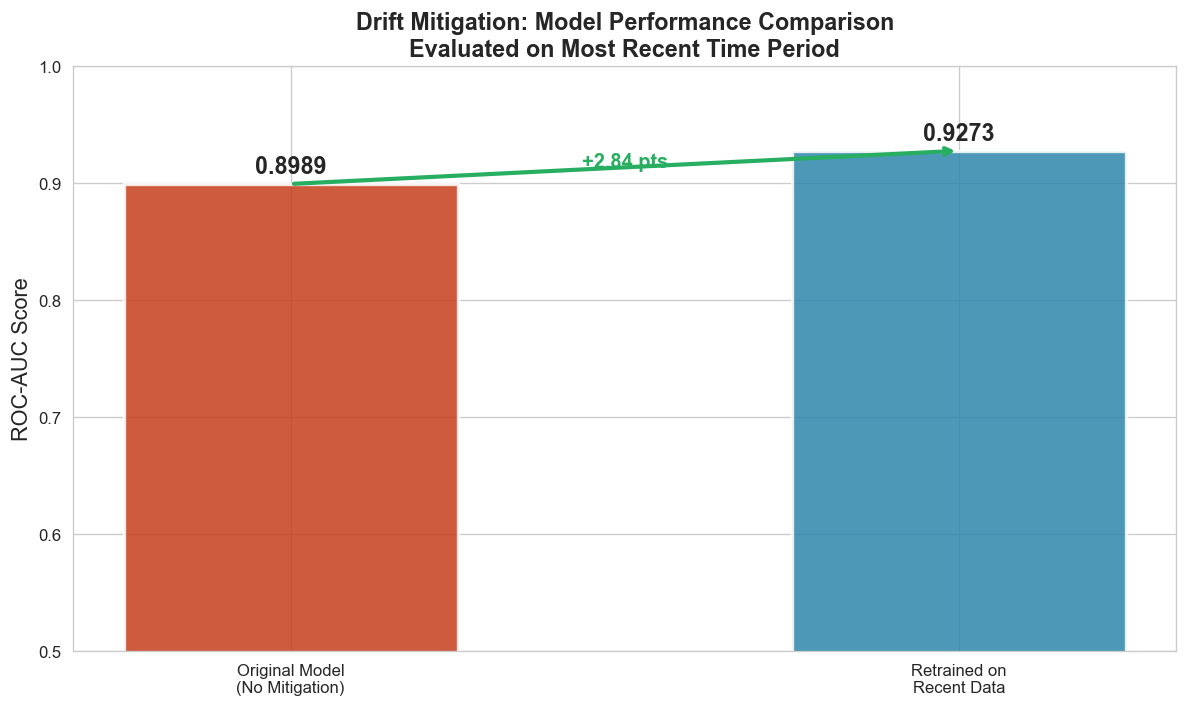

In [76]:
last_months = sorted(df['month_bin'].unique())[-4:]
df_recent = df[df['month_bin'].isin(last_months)]
X_rec = df_recent[FEATURE_COLS]
y_rec = df_recent[TARGET]

# Retrain on recent data
model_retrained = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_rec==0).sum()/(y_rec==1).sum(),
    use_label_encoder=False, eval_metric='auc',
    random_state=42, n_jobs=-1
)

# Use all but last month for retrain, last month for eval
eval_month = last_months[-1]
retrain_months = last_months[:-1]

df_retrain_x = df[df['month_bin'].isin(retrain_months)]
df_eval      = df[df['month_bin'] == eval_month]

model_retrained.fit(df_retrain_x[FEATURE_COLS], df_retrain_x[TARGET], verbose=False)

# Compare AUC on evaluation month
original_auc  = roc_auc_score(df_eval[TARGET], model.predict_proba(df_eval[FEATURE_COLS])[:,1])
retrained_auc = roc_auc_score(df_eval[TARGET], model_retrained.predict_proba(df_eval[FEATURE_COLS])[:,1])

print(f"\nEvaluation on most recent month ({eval_month}):")
print(f"   Original Model AUC  (trained on months 0-3): {original_auc:.4f}")
print(f"   Retrained Model AUC (trained on months {retrain_months[0]}-{retrain_months[-1]}): {retrained_auc:.4f}")
print(f"   Improvement: {(retrained_auc - original_auc)*100:+.2f} points")

# Visual comparison
strategies = ['Original Model\n(No Mitigation)', 'Retrained on\nRecent Data']
aucs = [original_auc, retrained_auc]
colors_bar = ['#C73E1D', '#2E86AB']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(strategies, aucs, color=colors_bar, alpha=0.85, width=0.5, edgecolor='white', linewidth=2)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('ROC-AUC Score', fontsize=13)
ax.set_title('Drift Mitigation: Model Performance Comparison\nEvaluated on Most Recent Time Period',
             fontsize=14, fontweight='bold')

for bar, auc_val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc_val:.4f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

improvement = retrained_auc - original_auc
arrow_color = '#27AE60' if improvement > 0 else '#E74C3C'
ax.annotate('', xy=(1, retrained_auc), xytext=(0, original_auc),
            arrowprops=dict(arrowstyle='->', color=arrow_color, lw=2.5))
ax.text(0.5, (original_auc + retrained_auc)/2, f'{improvement*100:+.2f} pts', 
        ha='center', fontsize=12, color=arrow_color, fontweight='bold')

plt.tight_layout()
plt.show()

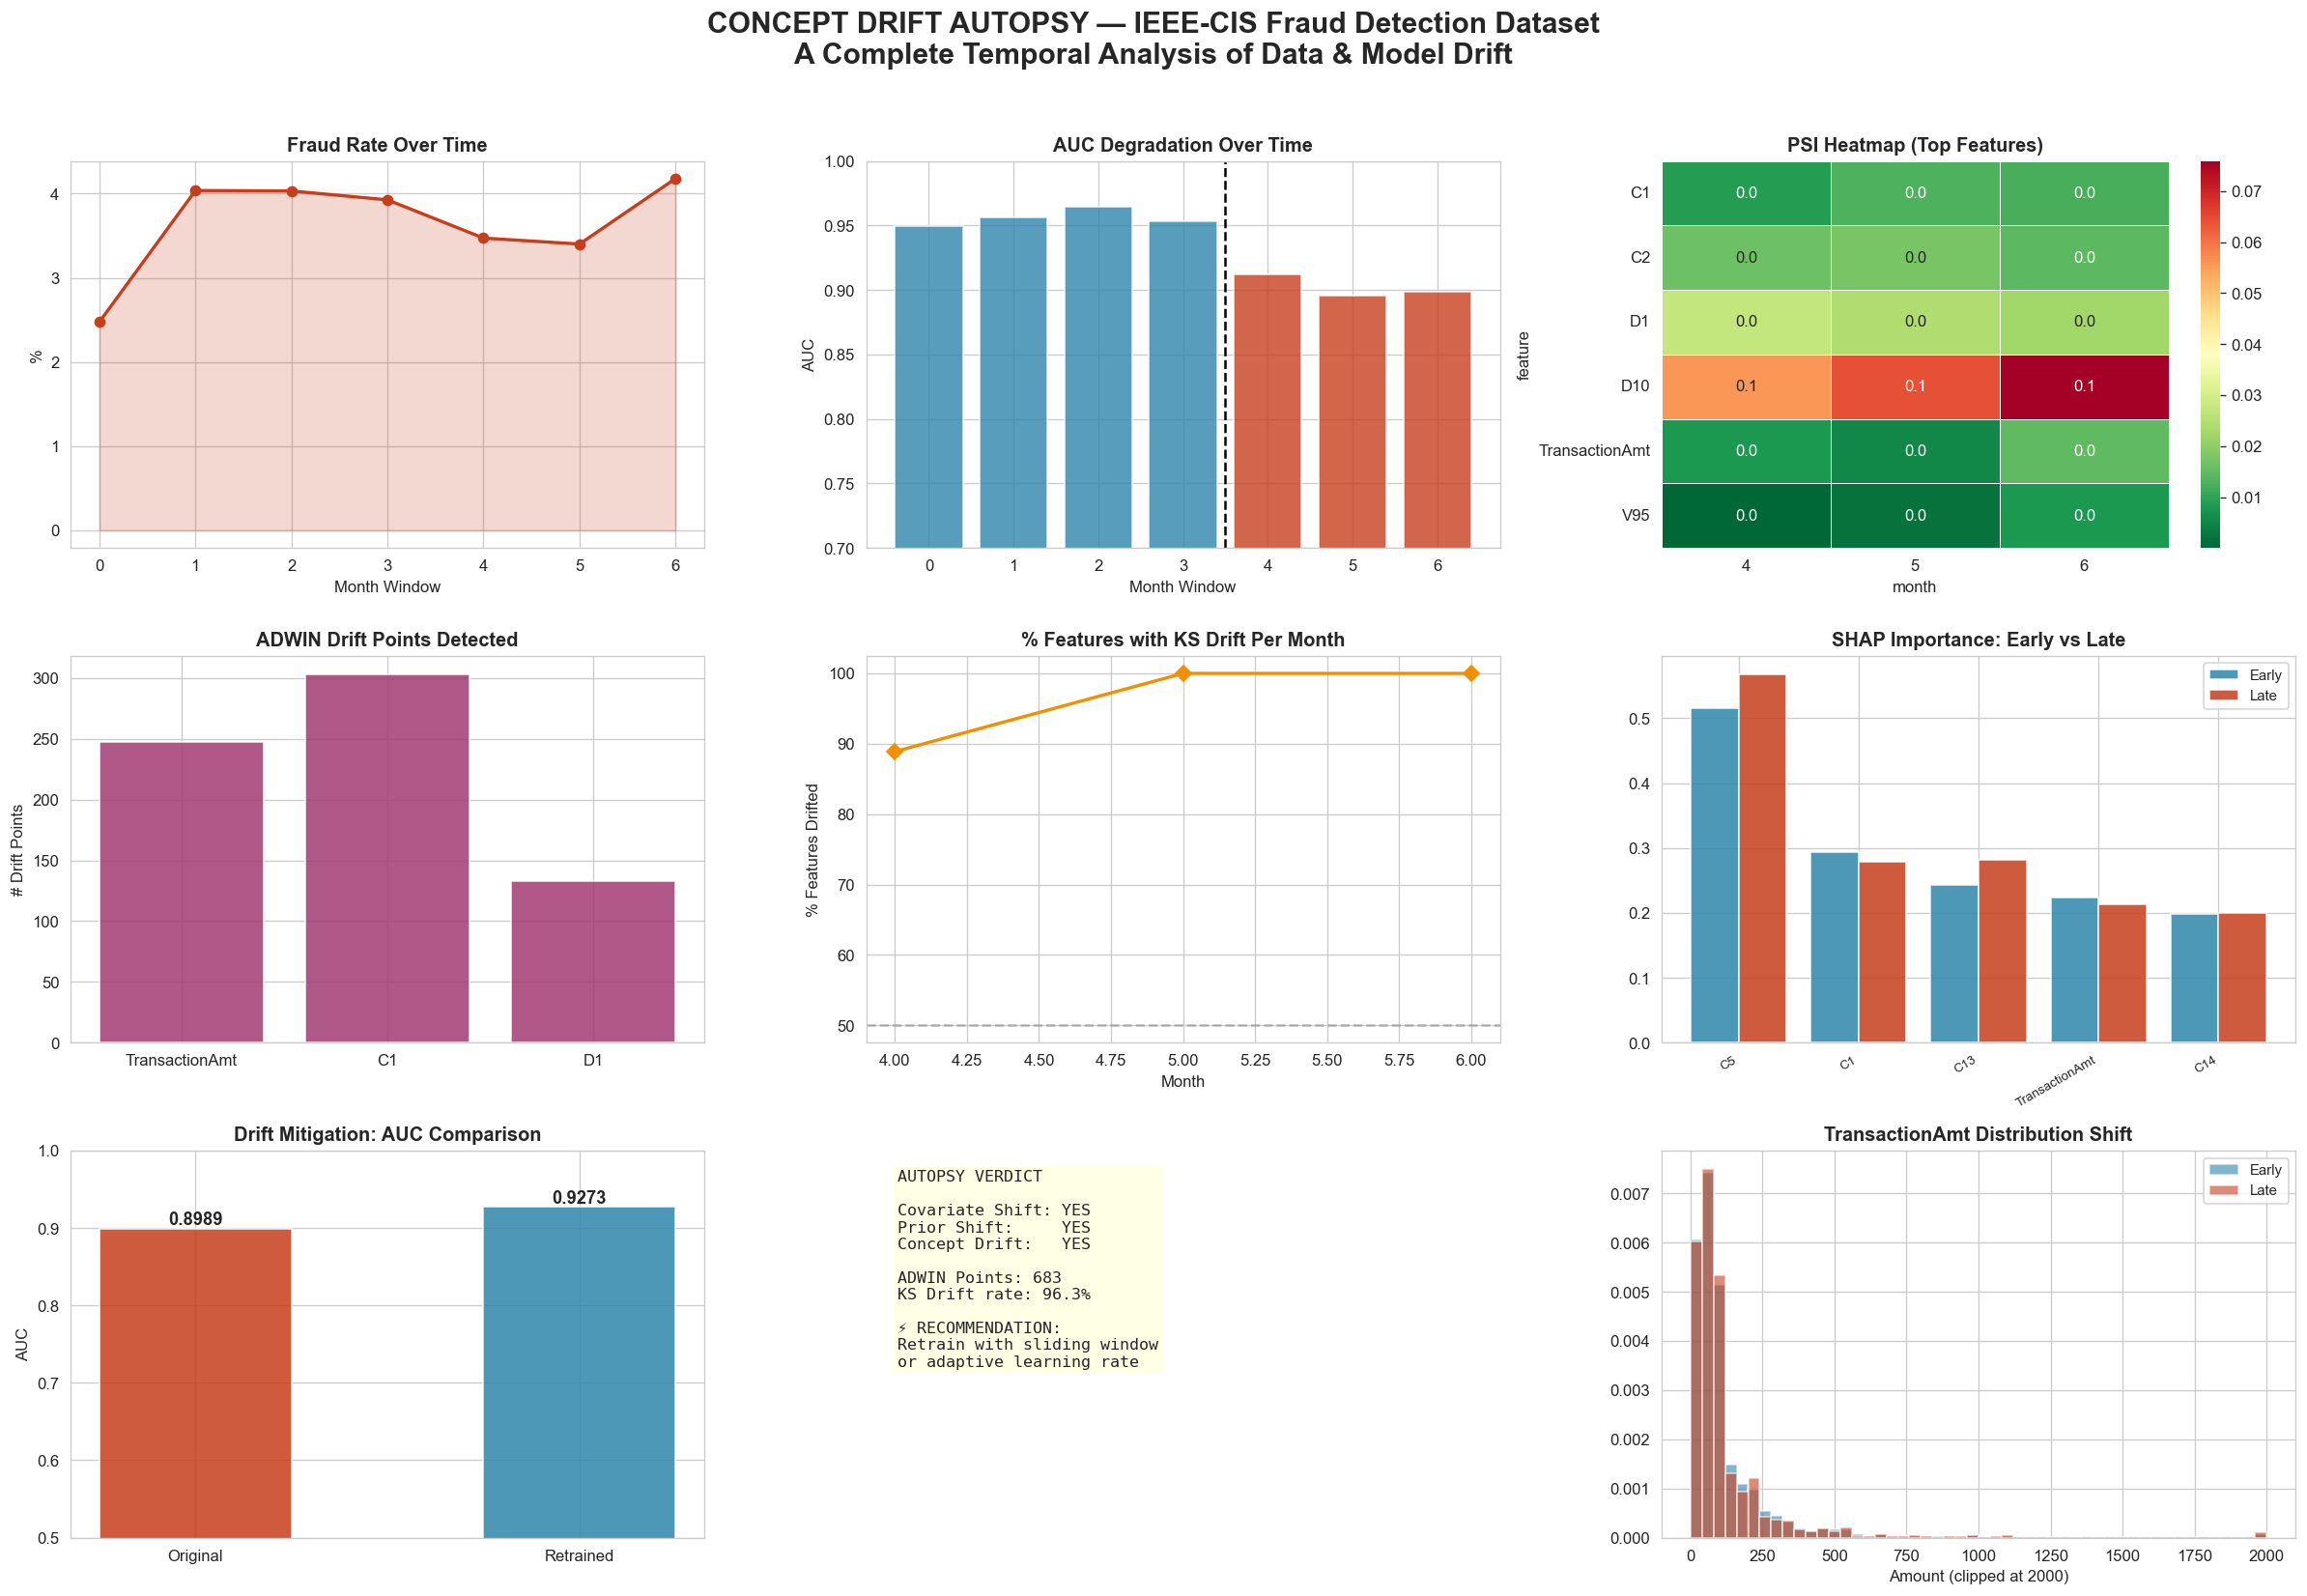

In [78]:
# =============================================
# CELL 12: FINAL PORTFOLIO DASHBOARD
# =============================================

fig = plt.figure(figsize=(20, 14))
fig.suptitle('CONCEPT DRIFT AUTOPSY — IEEE-CIS Fraud Detection Dataset\n'
             'A Complete Temporal Analysis of Data & Model Drift',
             fontsize=18, fontweight='bold', y=0.98)

# 1. Fraud Rate Over Time
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(fraud_by_month['month_bin'], fraud_by_month['fraud_rate']*100,
         'o-', color='#C73E1D', linewidth=2)
ax1.fill_between(fraud_by_month['month_bin'], fraud_by_month['fraud_rate']*100, alpha=0.2, color='#C73E1D')
ax1.set_title('Fraud Rate Over Time', fontweight='bold')
ax1.set_ylabel('%'); ax1.set_xlabel('Month Window')

# 2. AUC Over Time
ax2 = fig.add_subplot(3, 3, 2)
colors_bar2 = ['#2E86AB' if t else '#C73E1D' for t in metrics_df['is_train']]
ax2.bar(metrics_df['month'], metrics_df['auc'], color=colors_bar2, alpha=0.8)
ax2.axvline(x=3.5, color='black', linestyle='--')
ax2.set_title('AUC Degradation Over Time', fontweight='bold')
ax2.set_ylabel('AUC'); ax2.set_xlabel('Month Window')
ax2.set_ylim(0.7, 1.0)

# 3. PSI Heatmap (small)
ax3 = fig.add_subplot(3, 3, 3)
psi_small = psi_pivot.iloc[:6]
sns.heatmap(psi_small, ax=ax3, cmap='RdYlGn_r', cbar=True, annot=True, fmt='.1f', linewidths=0.5)
ax3.set_title('PSI Heatmap (Top Features)', fontweight='bold')

# 4. ADWIN drift points per feature
ax4 = fig.add_subplot(3, 3, 4)
adwin_counts = {k: len(v) for k, v in adwin_results.items()}
ax4.bar(adwin_counts.keys(), adwin_counts.values(), color='#A23B72', alpha=0.85)
ax4.set_title('ADWIN Drift Points Detected', fontweight='bold')
ax4.set_ylabel('# Drift Points')

# 5. KS Test — proportion drifted per month
ax5 = fig.add_subplot(3, 3, 5)
ks_by_month = drift_df.groupby('month')['ks_drift'].mean() * 100
ax5.plot(ks_by_month.index, ks_by_month.values, 'D-', color='#F18F01', linewidth=2, markersize=7)
ax5.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax5.set_title('% Features with KS Drift Per Month', fontweight='bold')
ax5.set_ylabel('% Features Drifted')
ax5.set_xlabel('Month')

# 6. SHAP importance top features early vs late
ax6 = fig.add_subplot(3, 3, 6)
top5 = (early_importance + late_importance).nlargest(5).index
x_ax = np.arange(len(top5))
ax6.bar(x_ax - 0.2, early_importance[top5], 0.4, label='Early', color='#2E86AB', alpha=0.85)
ax6.bar(x_ax + 0.2, late_importance[top5],  0.4, label='Late',  color='#C73E1D', alpha=0.85)
ax6.set_xticks(x_ax); ax6.set_xticklabels(top5, rotation=30, ha='right', fontsize=8)
ax6.set_title('SHAP Importance: Early vs Late', fontweight='bold')
ax6.legend(fontsize=9)

# 7. Mitigation bar chart
ax7 = fig.add_subplot(3, 3, 7)
ax7.bar(['Original', 'Retrained'], [original_auc, retrained_auc],
        color=['#C73E1D', '#2E86AB'], alpha=0.85, width=0.5)
ax7.set_ylim(0.5, 1.0)
ax7.set_title('Drift Mitigation: AUC Comparison', fontweight='bold')
ax7.set_ylabel('AUC')
for i, v in enumerate([original_auc, retrained_auc]):
    ax7.text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# 8. Drift Type Summary
ax8 = fig.add_subplot(3, 3, 8)
ax8.axis('off')
summary_text = [
    "AUTOPSY VERDICT",
    "",
    f"Covariate Shift: {'YES' if len(covariate_drifted)>3 else 'MILD'}",
    f"Prior Shift:     {'YES' if abs(fraud_rate_change[-1]-fraud_rate_change[0])>0.005 else 'NO'}",
    f"Concept Drift:   {'YES' if auc_early-auc_late>0.02 else 'MILD'}",
    "",
    f"ADWIN Points: {sum(len(v) for v in adwin_results.values())}",
    f"KS Drift rate: {drift_df['ks_drift'].mean()*100:.1f}%",
    "",
    "⚡ RECOMMENDATION:",
    "Retrain with sliding window",
    "or adaptive learning rate"
]
ax8.text(0.05, 0.95, '\n'.join(summary_text), transform=ax8.transAxes,
         fontsize=10, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 9. Transaction Amount Distribution Shift
ax9 = fig.add_subplot(3, 3, 9)
early_data = df[df['month_bin'].isin([0,1])]['TransactionAmt'].clip(0, 2000)
late_data  = df[df['month_bin'].isin(last_months[-2:])]['TransactionAmt'].clip(0, 2000)
ax9.hist(early_data, bins=50, alpha=0.6, color='#2E86AB', density=True, label='Early')
ax9.hist(late_data,  bins=50, alpha=0.6, color='#C73E1D', density=True, label='Late')
ax9.set_title('TransactionAmt Distribution Shift', fontweight='bold')
ax9.set_xlabel('Amount (clipped at 2000)'); ax9.legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()